# Evaluation Utilities

Reusable evaluation functions for testing models across different datasets and scenarios.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


def evaluate_model(model_path, test_data_path, binary_task=True, has_bert=False):
    """
    Comprehensive model evaluation with all metrics and visualizations.
    
    Parameters:
    -----------
    model_path : str
        Path to the saved model (.pkl file)
    test_data_path : str
        Path to test dataset CSV (must have 'Text', 'Writer', 'is_AI' columns)
    binary_task : bool
        True for binary AI detection or False for multiclass writer classification
    has_bert : bool
        Whether the model includes BERT embeddings (for feature comparison)
    Returns:
    --------
    dict : Dictionary containing accuracy, predictions, and other metrics
    """
    
    print("="*80)
    print(f"MODEL EVALUATION - {'BINARY' if binary_task else 'MULTICLASS'} CLASSIFICATION")
    print("="*80)
    
    model = joblib.load(model_path)
    
    df = pd.read_csv(test_data_path)
    
    if binary_task:
        X_test = df.drop(columns=['Text', 'Writer', 'is_AI'], errors='ignore')
        y_test = df['is_AI']
        class_names = ['Human', 'AI']
    else:  # multiclass
        X_test = df.drop(columns=['Text', 'Writer', 'is_AI'], errors='ignore')
        y_test = df['Writer']
        
        # Encode labels if needed
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        if y_test.dtype == 'object':
            y_test_encoded = le.fit_transform(y_test)
            class_names = le.classes_
        else:
            y_test_encoded = y_test
            class_names = sorted(y_test.unique())
        y_test = y_test_encoded
    
    # Convert to numeric
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0) 

    # -------------------------------------------------------------------------
    # FIX: Align test columns with model's expected columns
    # -------------------------------------------------------------------------
    try:
        model_booster = model.get_booster()
        model_feature_names = model_booster.feature_names
        
        # Check for missing columns
        missing_cols = [col for col in model_feature_names if col not in X_test.columns]
        if missing_cols:
            print(f"Warning: The following features expected by the model are missing in test data: {missing_cols}")
            # FIX: Add all missing columns at once using pd.concat to avoid fragmentation
            missing_df = pd.DataFrame(0.0, index=X_test.index, columns=missing_cols)
            X_test = pd.concat([X_test, missing_df], axis=1)
        
        # Reorder columns to match model exactly
        X_test = X_test[model_feature_names]
        print(f"✓ Columns aligned with model requirements ({len(model_feature_names)} features)")
        
    except Exception as e:
        print(f"Warning: Could not align columns automatically. Error: {e}")
        # Fallback: if feature names aren't available, rely on current X_test structure
    # -------------------------------------------------------------------------
    
    # Make predictions - convert to numpy to avoid CUDA/CPU mismatch
    print(f"\n Making predictions...")
    X_test_np = X_test.values.astype(np.float32)
    y_pred = model.predict(X_test_np)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Display accuracy
    print("\n" + "="*80)
    print(f"ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("="*80)
    
    # Classification Report
    print(f"\nClassification Report:")
    print("\n" + classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    
    # Confusion Matrix
    print(f"\nGenerating Confusion Matrix...")
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names, 
                cmap='Blues', 
                cbar_kws={'label': 'Count'},)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(f'Confusion Matrix - {"BINARY" if binary_task else "MULTICLASS"} Classification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature Importance
    print(f"\nAnalyzing Feature Importance...")
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(feature_importance_df.head(20).to_string(index=False))
    
    # Plot Top 20 Features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', 
                data=feature_importance_df.head(20), 
                palette='viridis', hue="Feature", legend=False)
    plt.title(f'Top 20 Features - {"BINARY" if binary_task else "MULTICLASS"} Classification', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score (Gain)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # BERT vs Manual Features Comparison (if applicable)
    if has_bert:
        print("\nBERT vs Manual Features Comparison...")
        
        # Identify BERT columns (assuming they start with 'bert_')
        bert_cols = [col for col in X_test.columns if col.startswith('bert_')]
        manual_cols = [col for col in X_test.columns if not col.startswith('bert_')]
        
        if len(bert_cols) > 0 and len(manual_cols) > 0:
            # Get indices
            bert_indices = [i for i, col in enumerate(X_test.columns) if col.startswith('bert_')]
            manual_indices = [i for i, col in enumerate(X_test.columns) if not col.startswith('bert_')]
            
            # Calculate mean importance for each group
            bert_importance = np.mean(importances[bert_indices])
            manual_importance = np.mean(importances[manual_indices])
            
            print(f"\nFeature Group Statistics:")
            print(f"  Manual Features: {len(manual_cols)} features, Mean Importance: {manual_importance:.6f}")
            print(f"  BERT Embeddings: {len(bert_cols)} features, Mean Importance: {bert_importance:.6f}")
            
            # Plot comparison
            plt.figure(figsize=(10, 6))
            bars = plt.bar(['Manual Stylometric', 'BERT Embeddings'], 
                          [manual_importance, bert_importance], 
                          color=['#3498db', '#2ecc71'])
            plt.ylabel('Mean Importance (Gain)', fontsize=12)
            plt.title('Feature Group Importance Comparison', fontsize=14, fontweight='bold')
            plt.grid(axis='y', linestyle='--', alpha=0.3)
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.6f}',
                        ha='center', va='bottom', fontsize=11)
            
            plt.tight_layout()
            plt.show()
        else:
            print("Warning: Could not identify BERT features (expected columns starting with 'bert_')")
    
    # Return results
    results = {
        'accuracy': accuracy,
        'predictions': y_pred,
        'true_labels': y_test,
        'confusion_matrix': cm,
        'feature_importance': feature_importance_df,
        'classification_report': classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    }
    
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)
    
    return results


def compare_models(title,model_results_dict, metric='accuracy'):
    """
    Compare multiple model evaluation results.
    Parameters:
    -----------
    title : str
        Title for the comparison
    model_results_dict : dict
        Dictionary with model names as keys and results dictionaries as values
    metric : str
        Metric to compare ('accuracy', 'precision', 'recall', 'f1-score')
    """
    print("\n" + "="*80)
    print("MODEL COMPARISON")
    print("="*80)
    
    comparison_data = []
    for model_name, results in model_results_dict.items():
        comparison_data.append({
            'Model': model_name,
            metric: results[metric]
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values(metric, ascending=False)
    
    print("\n" + comparison_df.to_string(index=False))
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.barh(comparison_df['Model'], comparison_df[metric], color='steelblue')
    plt.xlabel(metric.capitalize(), fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Testing 

## Test on misspelled Data

MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.1956 (19.56%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.15      0.99      0.26       366
          AI       0.99      0.06      0.12      2201

    accuracy                           0.20      2567
   macro avg       0.57      0.53      0.19      2567
weighted avg       0.87      0.20      0.14      2567


Generating Confusion Matrix...


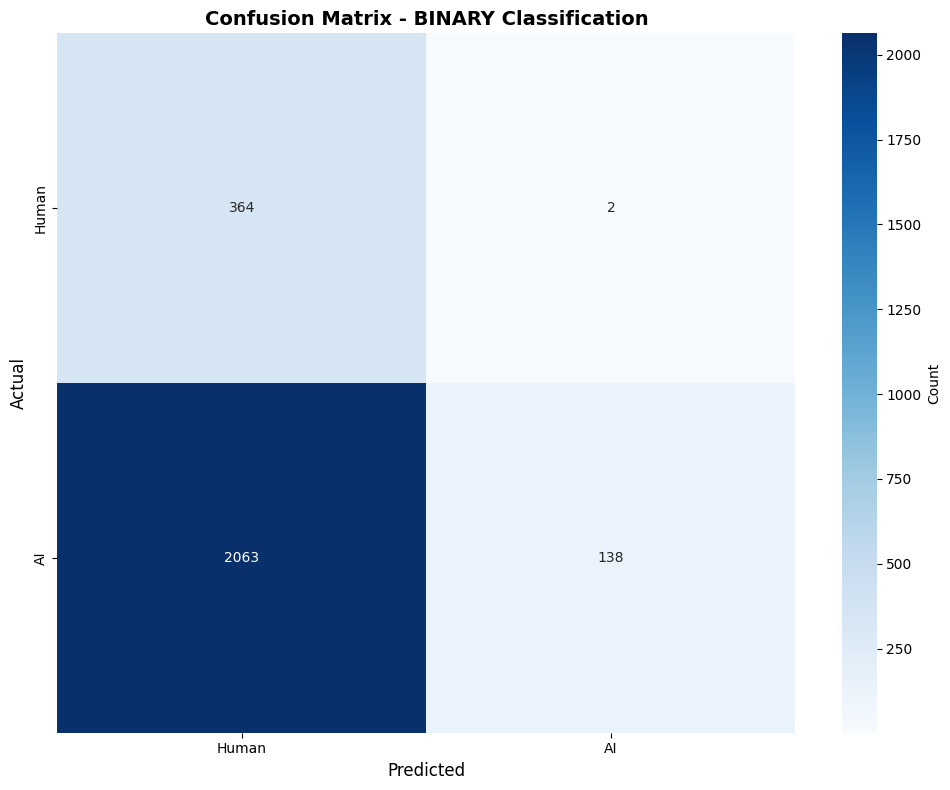


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


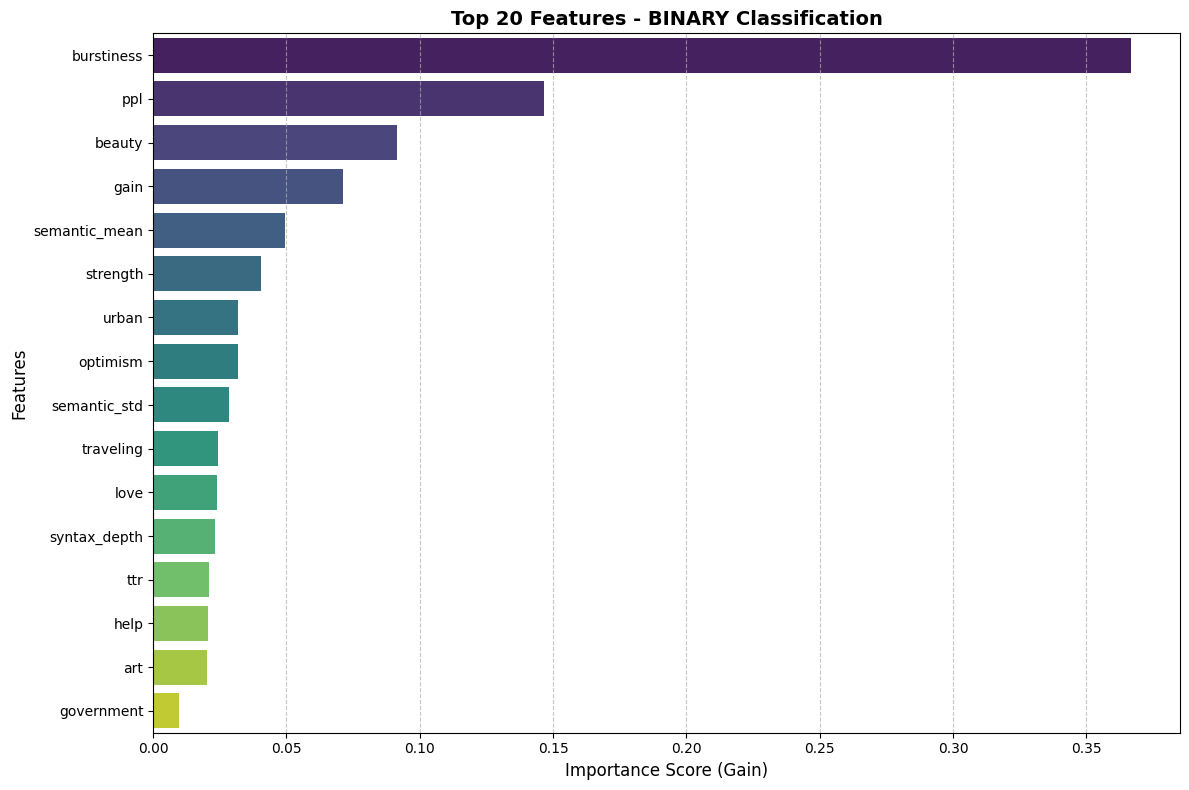


EVALUATION COMPLETE!


In [70]:
# AI Detection Model Evaluation with misspelling attack
results_misspelled_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/misspelled/DB_final.csv',
    binary_task=True,
)

In [ ]:
# AI Detection With BERT Model Evaluation with misspelling attack
results_misspelled_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/misspelled/DB_final.csv',
    binary_task=True,
    has_bert=True
)

MODEL EVALUATION - MULTICLASS CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.1644 (16.44%)

Classification Report:

                                   precision    recall  f1-score   support

                          GPT_4-o       0.57      0.15      0.23       367
                      Human_story       0.15      1.00      0.26       366
accounts/yi-01-ai/models/yi-large       0.00      0.00      0.00       367
                       gemma-2-9b       0.00      0.00      0.00       367
                         llama-8B       1.00      0.01      0.02       367
                       mistral-7B       0.00      0.00      0.00       367
                       qwen-2-72B       0.00      0.00      0.00       366

                         accuracy                           0.16      2567
                        macro avg       0.25      0.16      0.07      2567
                     weighted avg       0.25      0.16      0.07      2

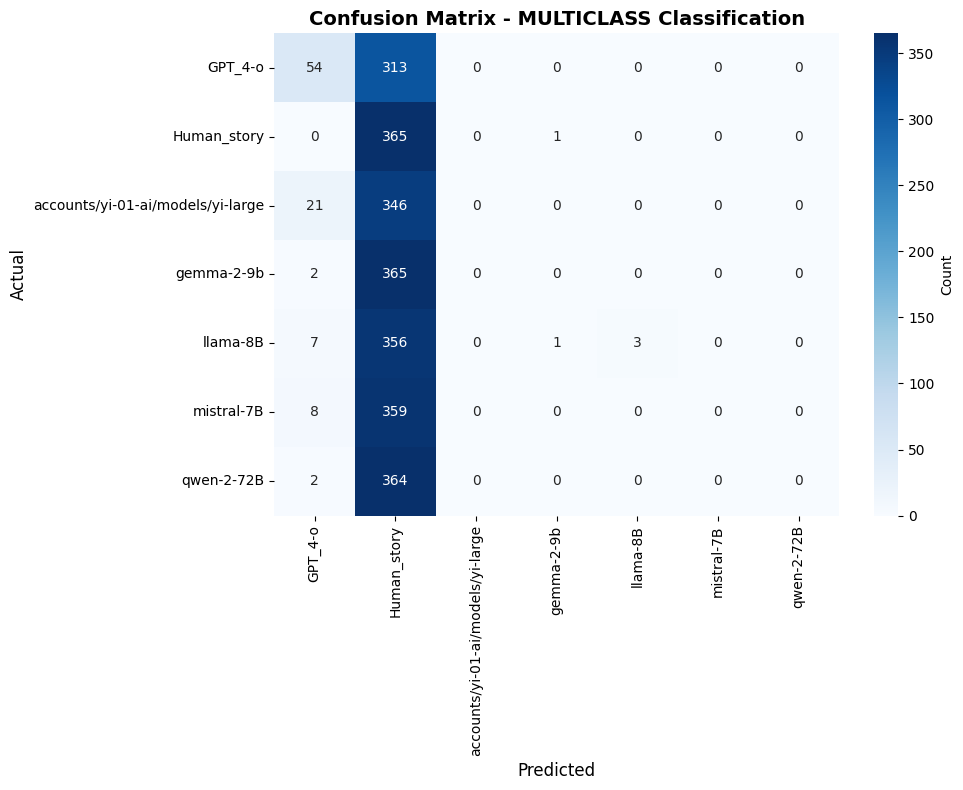


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
          ppl    0.196564
   burstiness    0.128036
          ttr    0.085467
         gain    0.061259
 syntax_depth    0.057697
       beauty    0.054924
        urban    0.050850
     strength    0.049065
semantic_mean    0.043782
         help    0.043670
         love    0.041674
   government    0.040752
    traveling    0.039667
          art    0.038319
     optimism    0.036777
 semantic_std    0.031499


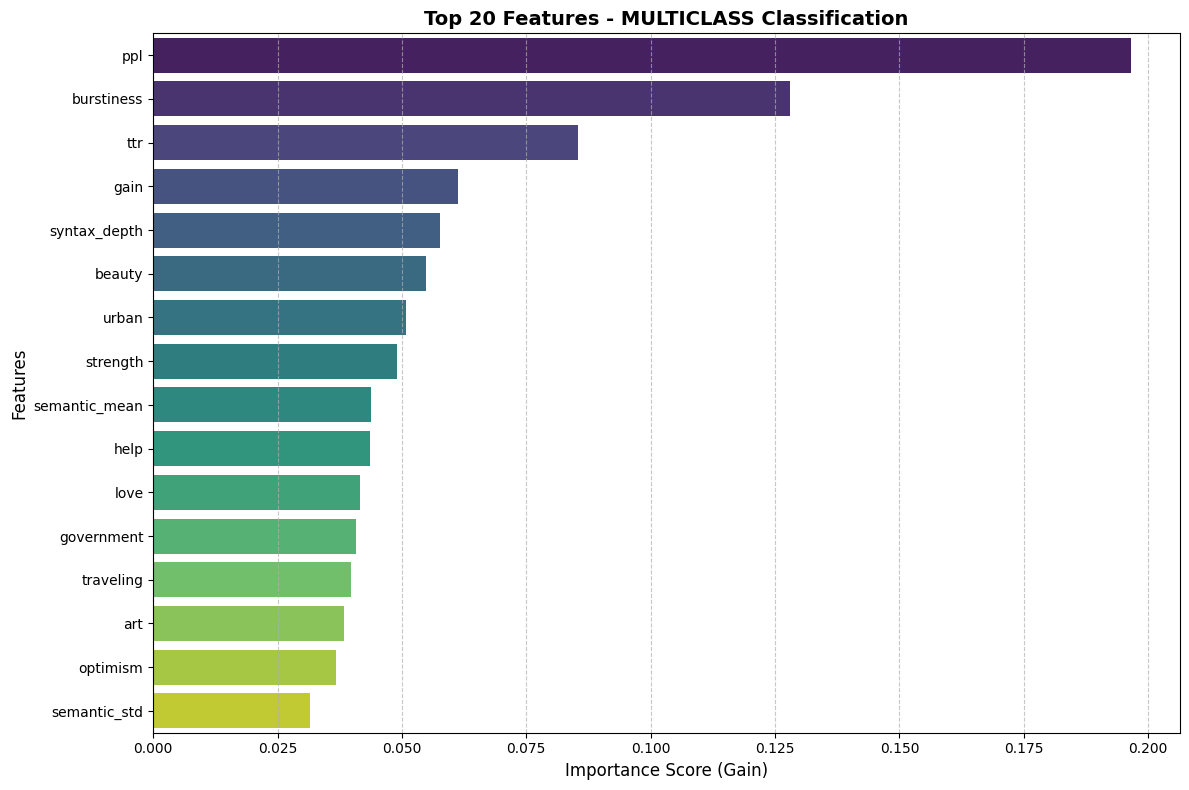


EVALUATION COMPLETE!


In [71]:
# Model classification on misspelled data
ts_misspelled_multiclass = evaluate_model(
    model_path='../models/xgb_classifier_model.pkl',
    test_data_path='../data/misspelled/DB_final.csv',
    binary_task=False,
)

In [ ]:
# Model classification with BERT on misspelled data
results_misspelled_multiclass_bert = evaluate_model(
    model_path='../models/xgb_classifier_with_BERT.pkl',
    test_data_path='../data/misspelled/DB_final.csv',
    binary_task=False,
    has_bert=True
)

In [72]:
df=pd.read_csv('../data/misspelled/DB_final.csv')
df["Writer"].value_counts()

Writer
gemma-2-9b                           367
mistral-7B                           367
llama-8B                             367
accounts/yi-01-ai/models/yi-large    367
GPT_4-o                              367
Human_story                          366
qwen-2-72B                           366
Name: count, dtype: int64

## Test on Cross-Domain Data

MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.7045 (70.45%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.42      0.59       200
          AI       0.63      0.99      0.77       196

    accuracy                           0.70       396
   macro avg       0.80      0.71      0.68       396
weighted avg       0.80      0.70      0.68       396


Generating Confusion Matrix...


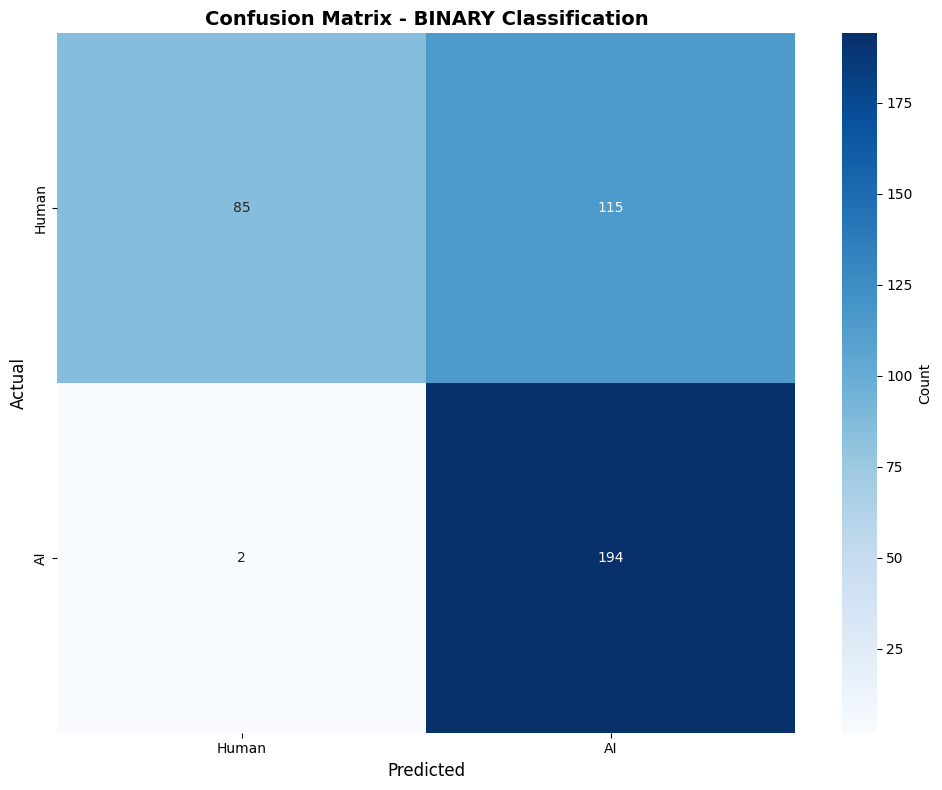


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


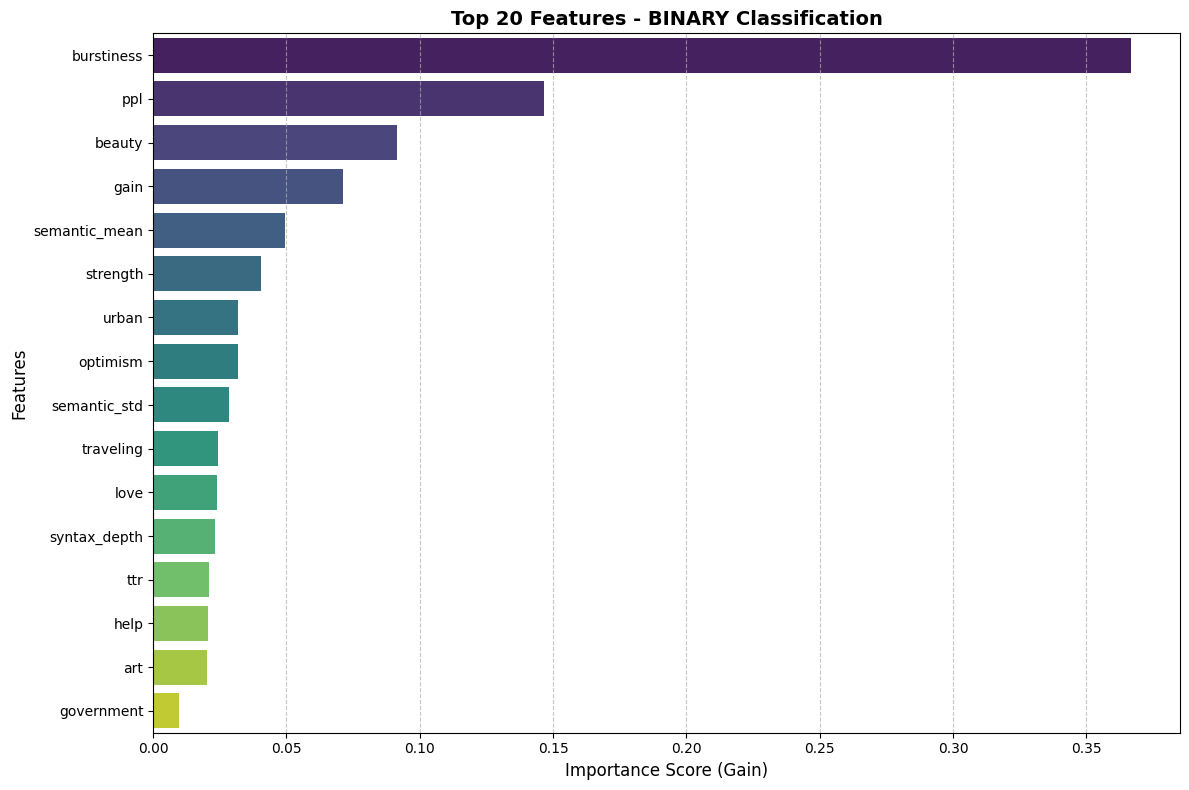


EVALUATION COMPLETE!
MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.9271 (92.71%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.95      0.91      0.93       200
          AI       0.91      0.95      0.93       198

    accuracy                           0.93       398
   macro avg       0.93      0.93      0.93       398
weighted avg       0.93      0.93      0.93       398


Generating Confusion Matrix...


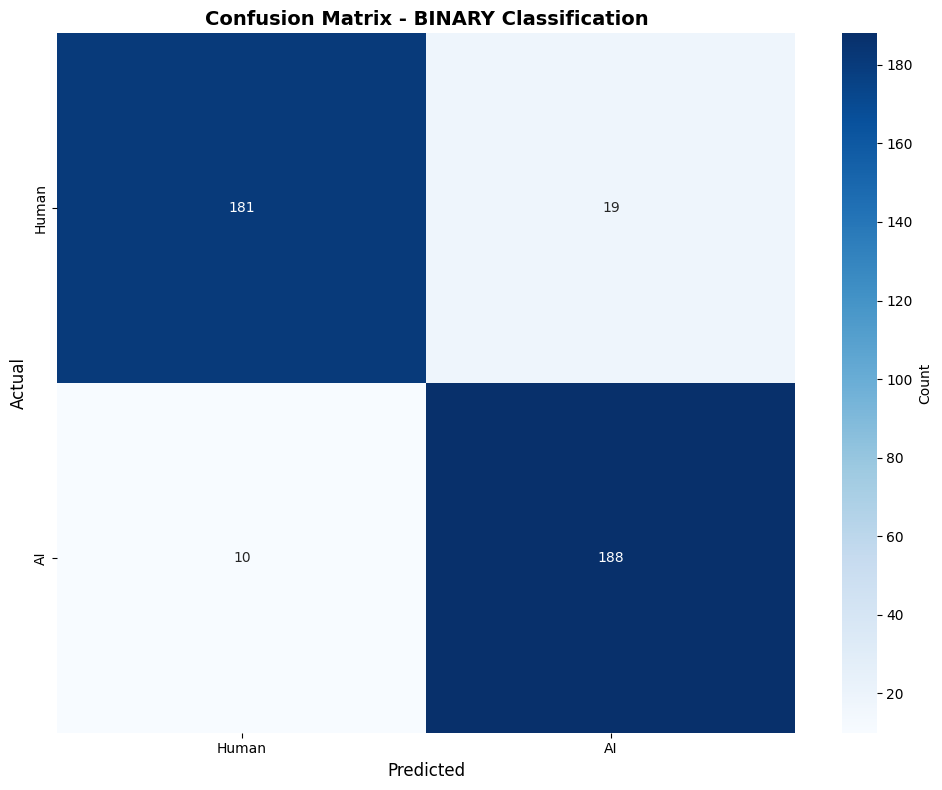


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


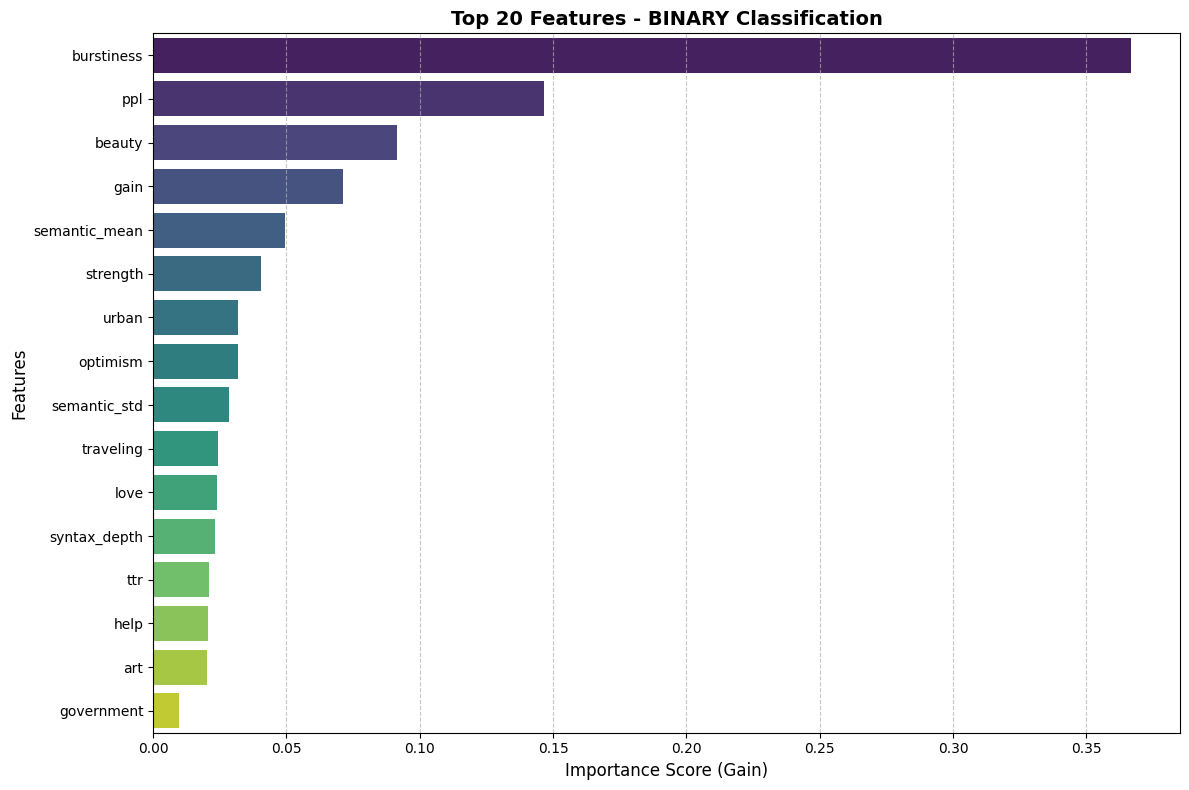


EVALUATION COMPLETE!


In [73]:
# AI Detection Model Evaluation with cross-domain data (Essay)
results_crossdomain_essay_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/Essay/DB_final.csv',
    binary_task=True,
)

# AI Detection Model Evaluation with cross-domain data (WP)
results_crossdomain_wp_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/WP/DB_final.csv',
    binary_task=True,
)

In [ ]:
# AI Detection With BERT Model Evaluation with cross-domain (Essay)
results_crossdomain_essay_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/Essay/DB_final.csv',
    binary_task=True,
    has_bert=True
)

# AI Detection With BERT Model Evaluation with cross-domain (WP)
results_crossdomain_wp_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/WP/DB_final.csv',
    binary_task=True,
    has_bert=True
)

# Model classification with BERT on cross-domain data (Essay)
results_crossdomain_essay_multiclass_bert = evaluate_model(
    model_path='../models/xgb_classifier_with_BERT.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/Essay/DB_final.csv',
    binary_task=False,
    has_bert=True
)

# Model classification with BERT on cross-domain data (WP)
results_crossdomain_wp_multiclass_bert = evaluate_model(
    model_path='../models/xgb_classifier_with_BERT.pkl',
    test_data_path='../data/MTG_Benchmark/Cross-Domain/WP/DB_final.csv',
    binary_task=False,
    has_bert=True
)

In [ ]:
df=pd.read_csv("../data/MTG_Benchmark/Cross-Domain/Essay/DB_final.csv")
df["Writer"].value_counts()

Writer
human      200
GPT4All    196
Name: count, dtype: int64

## Test on unseen model

MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.6725 (67.25%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.86      0.41      0.56       200
          AI       0.61      0.93      0.74       200

    accuracy                           0.67       400
   macro avg       0.73      0.67      0.65       400
weighted avg       0.73      0.67      0.65       400


Generating Confusion Matrix...


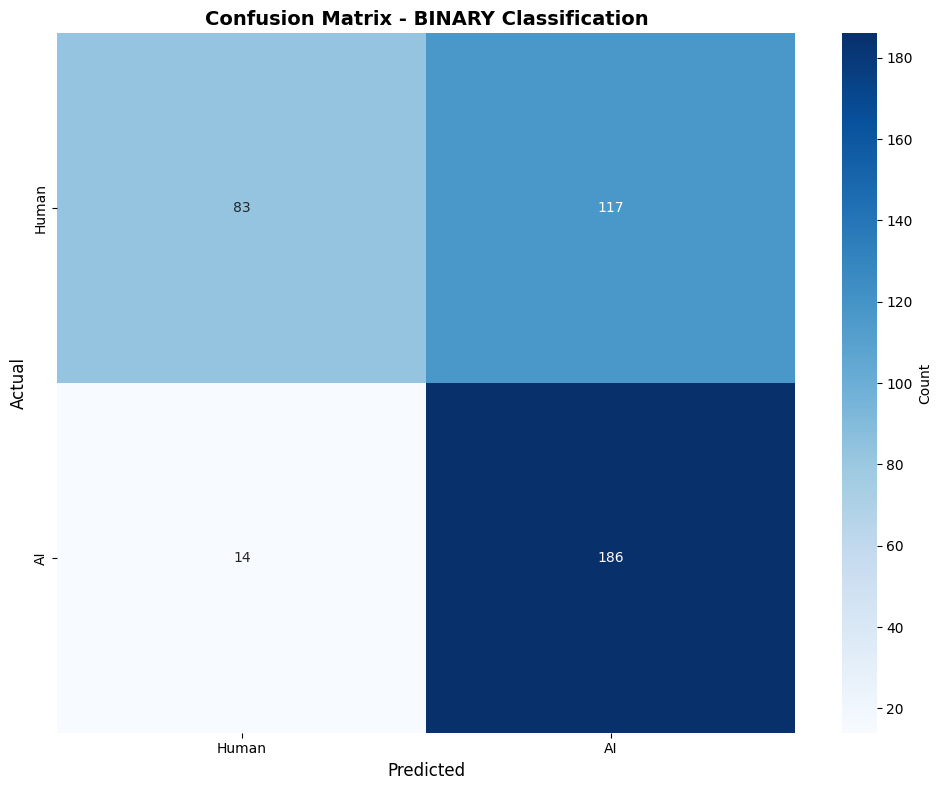


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


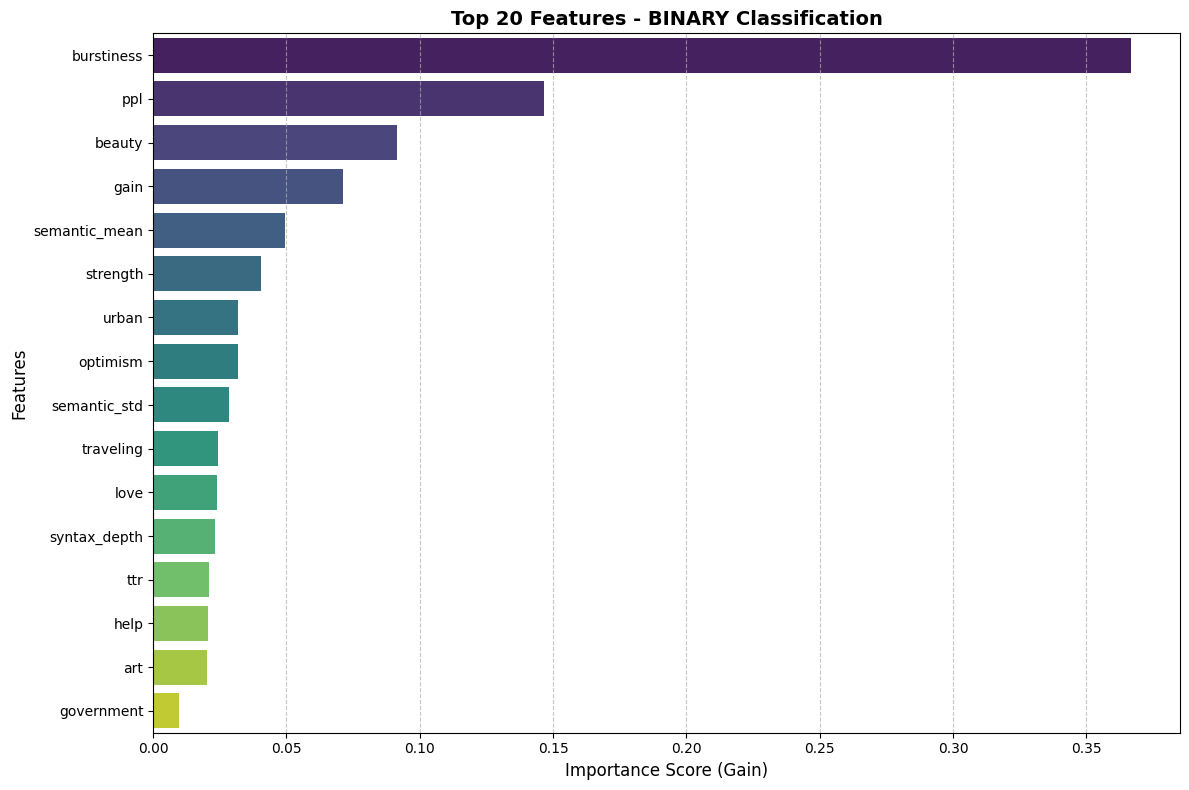


EVALUATION COMPLETE!


In [ ]:
# AI Detection Model Evaluation with unseen generators
results_unseen_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/MTG_Benchmark/unseen/DB_final.csv',
    binary_task=True,
)

In [ ]:
# AI Detection With BERT Model Evaluation with unseen generators
results_unseen_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/MTG_Benchmark/unseen/DB_final.csv',
    binary_task=True,
    has_bert=True
)

## Test on paraphrasing

MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.8020 (80.20%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.32      0.70      0.44        54
          AI       0.96      0.81      0.88       441

    accuracy                           0.80       495
   macro avg       0.64      0.76      0.66       495
weighted avg       0.89      0.80      0.83       495


Generating Confusion Matrix...


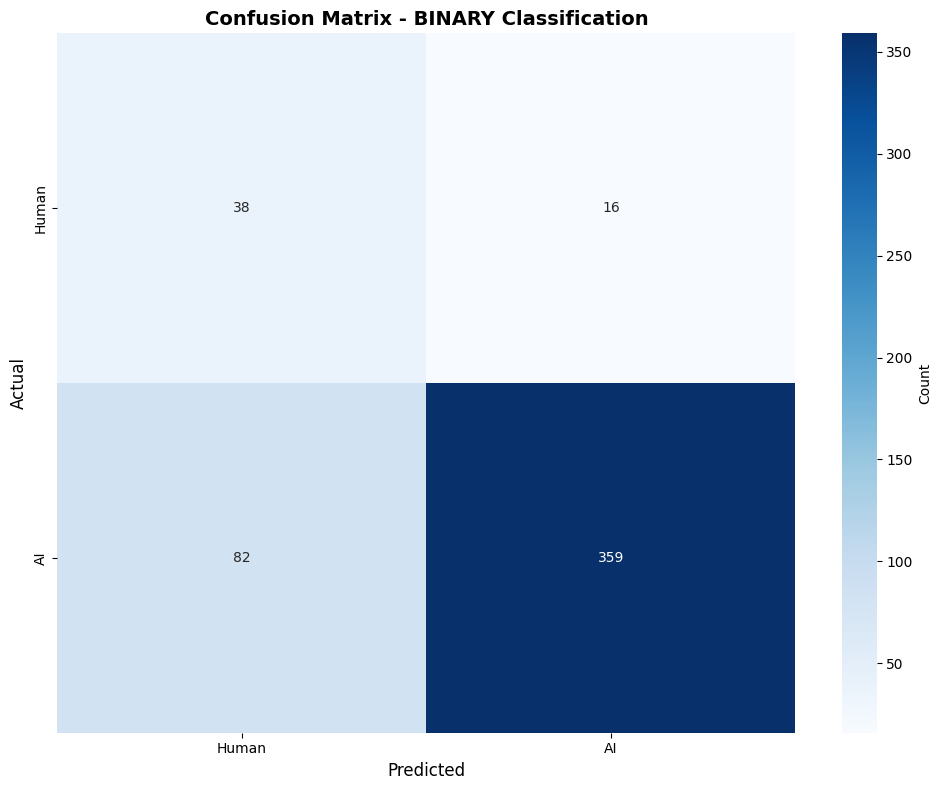


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


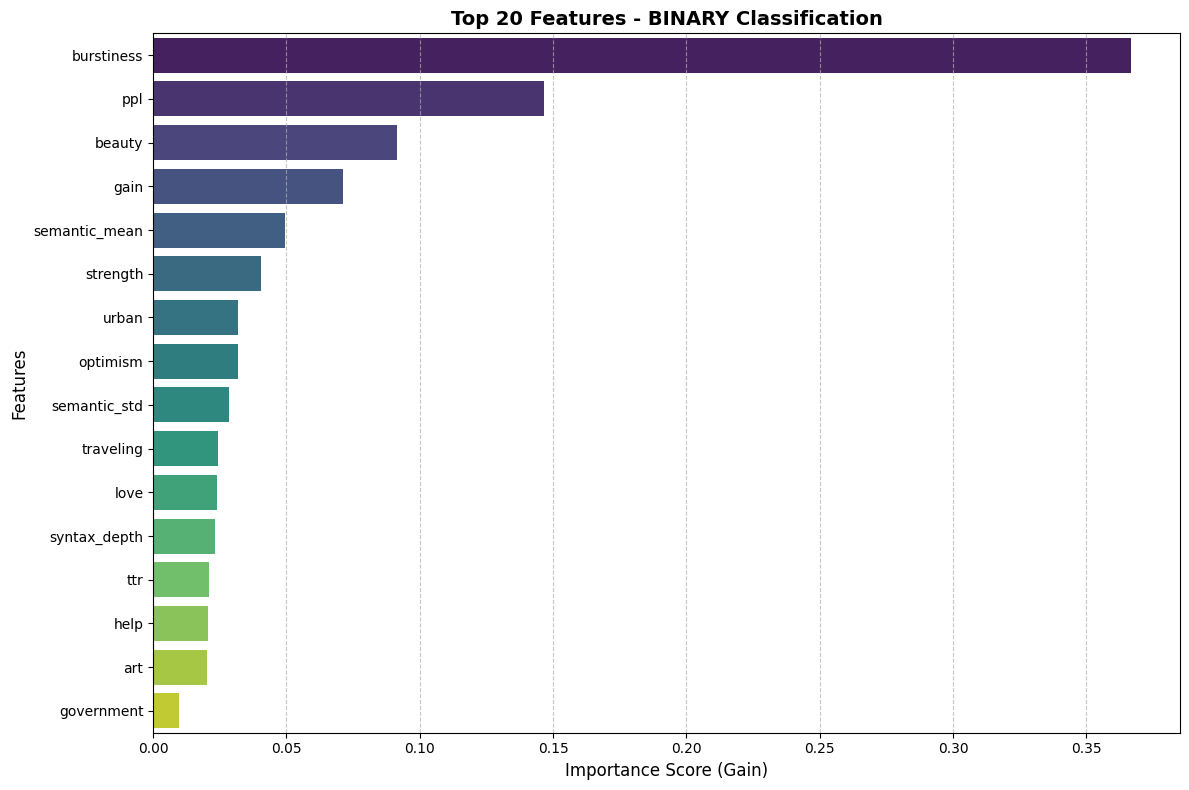


EVALUATION COMPLETE!


In [ ]:
# AI Detection Model Evaluation with paraphrasing attack
results_paraphrase_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/paraphrasing/gemini/DB_final.csv',
    binary_task=True
)

In [ ]:
# AI Detection With BERT Model Evaluation with paraphrasing attack
results_paraphrase_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/paraphrasing/gemini/DB_final.csv',
    binary_task=True,
    has_bert=True
)

MODEL EVALUATION - MULTICLASS CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.2040 (20.40%)

Classification Report:

                         precision    recall  f1-score   support

    GPT_4-o_paraphrased       0.63      0.15      0.24        82
Human_story_paraphrased       0.29      0.78      0.42        54
 gemma-2-9b_paraphrased       0.16      0.06      0.08        71
   llama-8B_paraphrased       0.14      0.70      0.24        61
 mistral-7B_paraphrased       0.00      0.00      0.00        80
 qwen-2-72B_paraphrased       0.00      0.00      0.00        79
   yi-large_paraphrased       0.00      0.00      0.00        68

               accuracy                           0.20       495
              macro avg       0.17      0.24      0.14       495
           weighted avg       0.18      0.20      0.13       495


Generating Confusion Matrix...


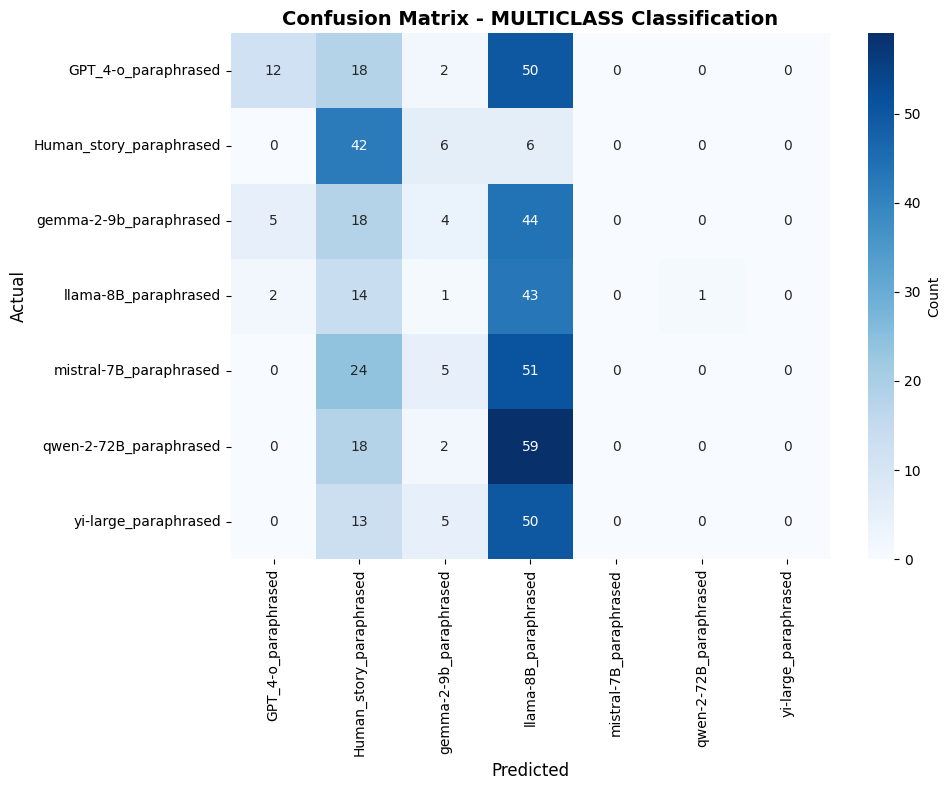


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
          ppl    0.196564
   burstiness    0.128036
          ttr    0.085467
         gain    0.061259
 syntax_depth    0.057697
       beauty    0.054924
        urban    0.050850
     strength    0.049065
semantic_mean    0.043782
         help    0.043670
         love    0.041674
   government    0.040752
    traveling    0.039667
          art    0.038319
     optimism    0.036777
 semantic_std    0.031499


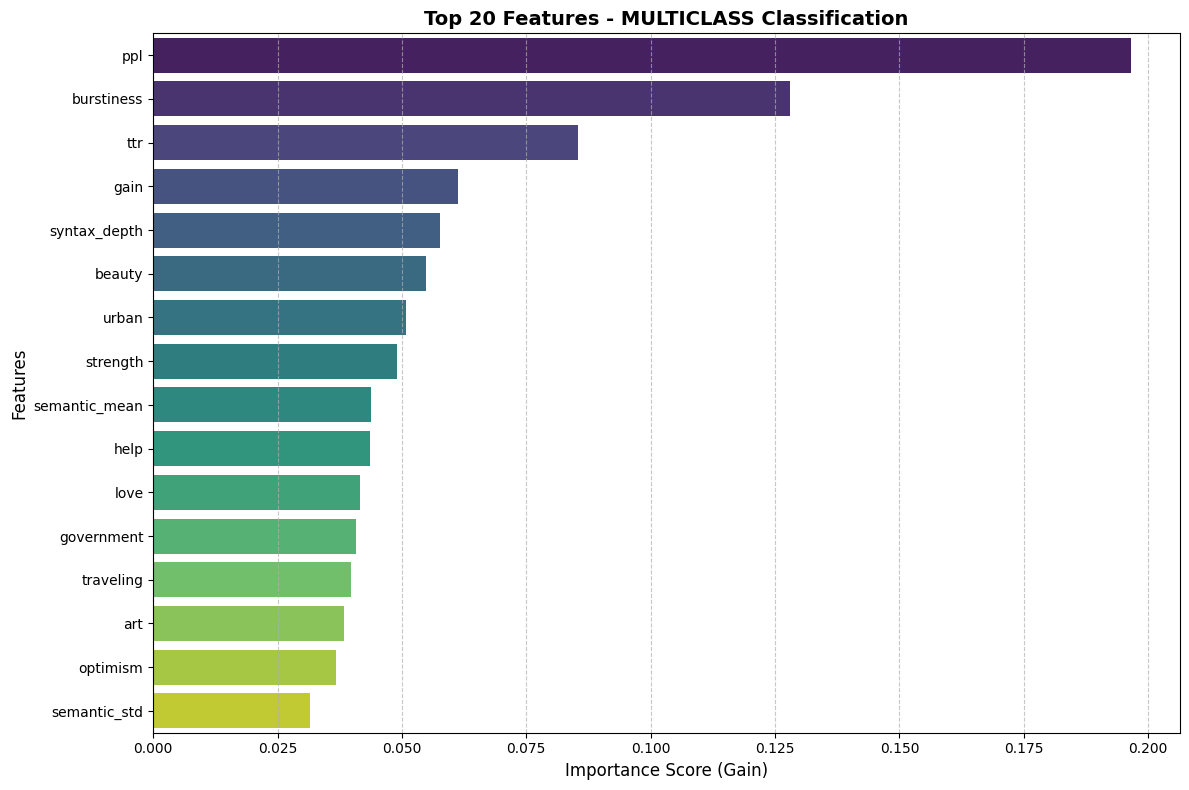


EVALUATION COMPLETE!


In [ ]:
# Model classification on paraphrasing data
results_paraphrase_multiclass = evaluate_model(
    model_path='../models/xgb_classifier_model.pkl',
    test_data_path='../data/paraphrasing/gemini/DB_final.csv',
    binary_task=False,
)

In [ ]:
# Model classification with BERT on paraphrasing data
results_paraphrase_multiclass_bert = evaluate_model(
    model_path='../models/xgb_classifier_with_BERT.pkl',
    test_data_path='../data/paraphrasing/gemini/DB_final.csv',
    binary_task=False,
    has_bert=True
)

## Test on Translation

MODEL EVALUATION - BINARY CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.9964 (99.64%)

Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.98      0.98       247
          AI       1.00      1.00      1.00      2817

    accuracy                           1.00      3064
   macro avg       0.99      0.99      0.99      3064
weighted avg       1.00      1.00      1.00      3064


Generating Confusion Matrix...


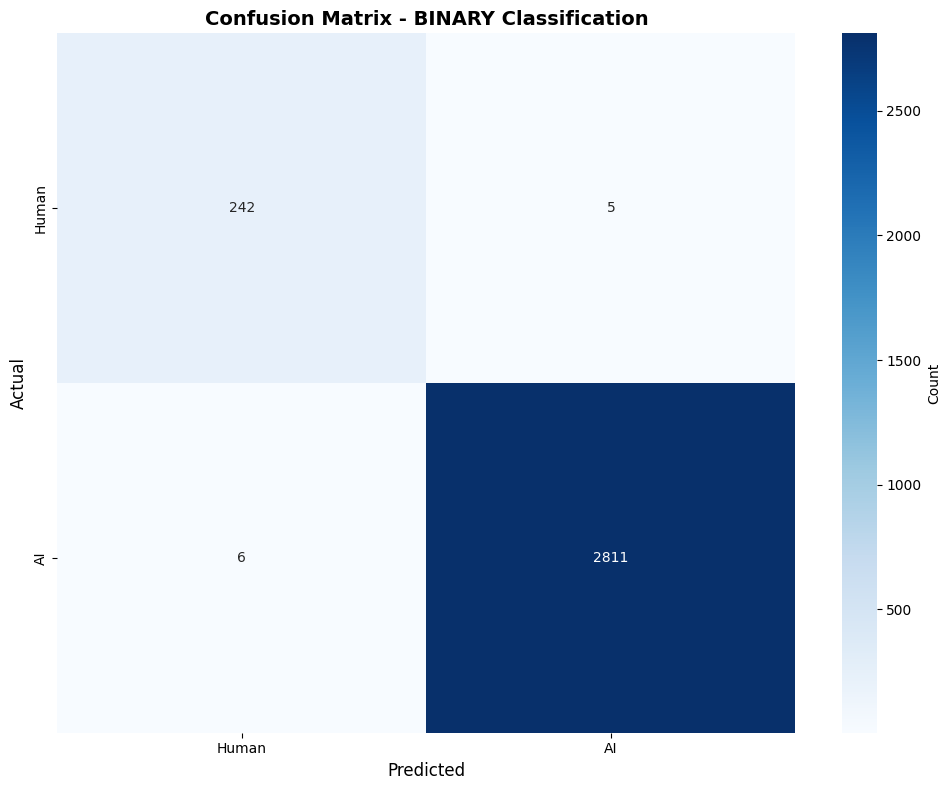


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
   burstiness    0.366744
          ppl    0.146635
       beauty    0.091266
         gain    0.071022
semantic_mean    0.049538
     strength    0.040370
        urban    0.031870
     optimism    0.031642
 semantic_std    0.028292
    traveling    0.024355
         love    0.024064
 syntax_depth    0.023170
          ttr    0.020769
         help    0.020385
          art    0.020191
   government    0.009686


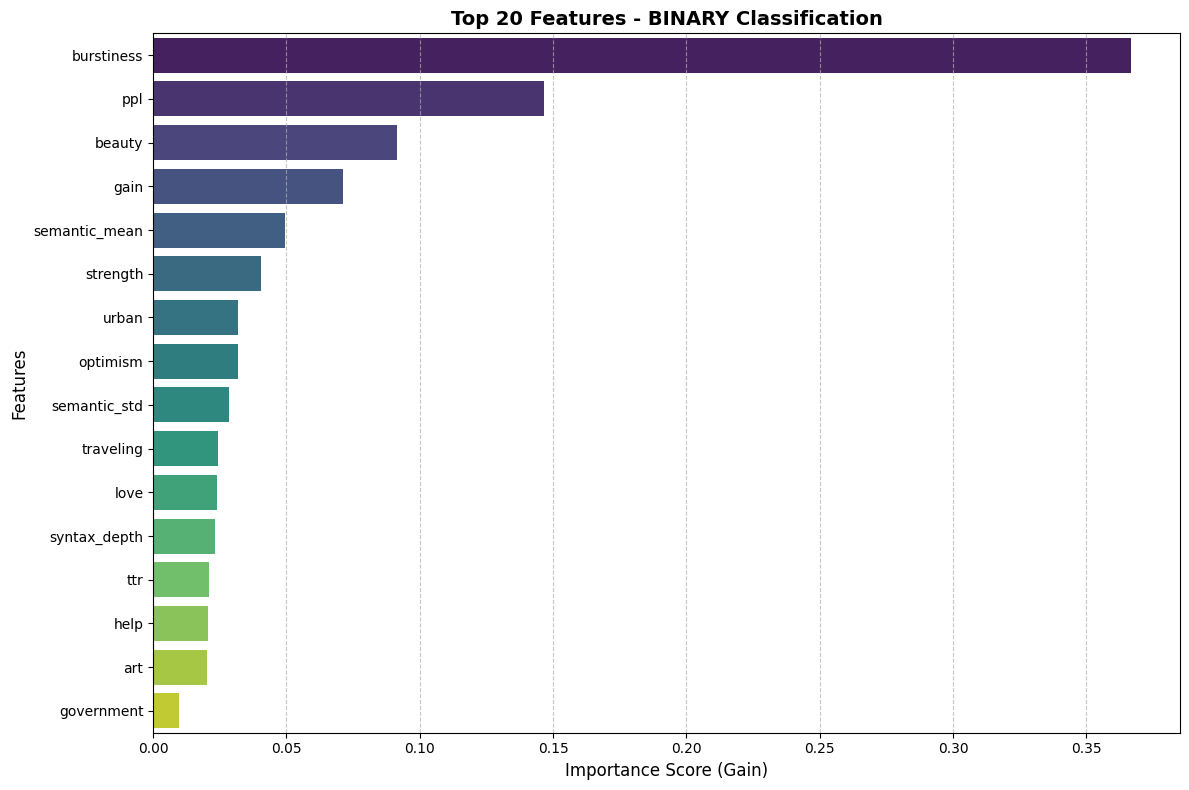


EVALUATION COMPLETE!


In [ ]:
# AI Detection Model Evaluation with translation attack
results_translation_binary = evaluate_model(
    model_path='../models/xgb_is_ai_model.pkl',
    test_data_path='../data/paraphrasing/nllb/DB_final.csv',
    binary_task=True,
)

In [ ]:
# AI Detection With BERT Model Evaluation with translation attack
results_translation_binary_bert = evaluate_model(
    model_path='../models/xgb_is_ai_with_BERT.pkl',
    test_data_path='../data/paraphrasing/nllb/DB_final.csv',
    binary_task=True,
    has_bert=True
)

MODEL EVALUATION - MULTICLASS CLASSIFICATION
✓ Columns aligned with model requirements (16 features)

 Making predictions...

ACCURACY: 0.2578 (25.78%)

Classification Report:

                        precision    recall  f1-score   support

    GPT_4-o_translated       0.85      0.85      0.85       449
Human_story_translated       0.90      0.93      0.91       247
 gemma-2-9b_translated       0.02      0.02      0.02       474
   llama-8B_translated       0.02      0.02      0.02       473
 mistral-7B_translated       0.17      0.16      0.17       476
 qwen-2-72B_translated       0.15      0.15      0.15       474
   yi-large_translated       0.02      0.02      0.02       471

              accuracy                           0.26      3064
             macro avg       0.31      0.31      0.31      3064
          weighted avg       0.26      0.26      0.26      3064


Generating Confusion Matrix...


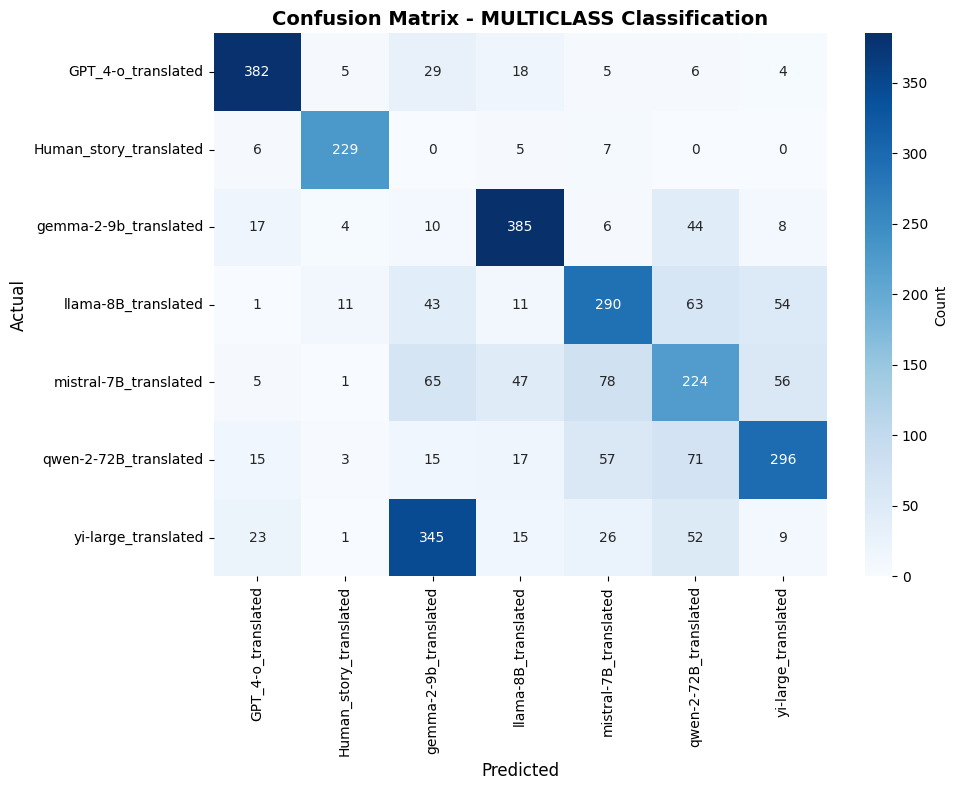


Analyzing Feature Importance...

Top 20 Most Important Features:
      Feature  Importance
          ppl    0.196564
   burstiness    0.128036
          ttr    0.085467
         gain    0.061259
 syntax_depth    0.057697
       beauty    0.054924
        urban    0.050850
     strength    0.049065
semantic_mean    0.043782
         help    0.043670
         love    0.041674
   government    0.040752
    traveling    0.039667
          art    0.038319
     optimism    0.036777
 semantic_std    0.031499


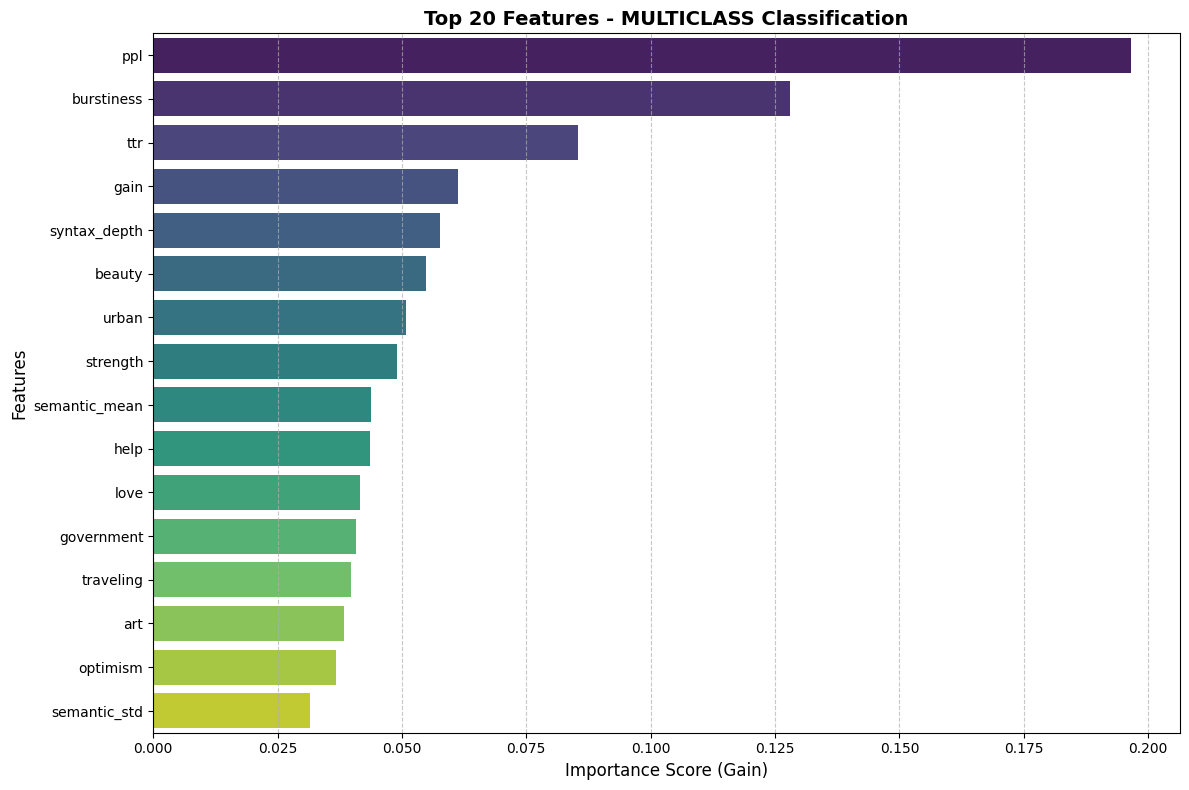


EVALUATION COMPLETE!


In [ ]:
# Model classification on translation data
results_translation_multiclass = evaluate_model(
    model_path='../models/xgb_classifier_model.pkl',
    test_data_path='../data/paraphrasing/nllb/DB_final.csv',
    binary_task=False,
)

In [ ]:
# Model classification with BERT on translation data
results_translation_multiclass_bert = evaluate_model(
    model_path='../models/xgb_classifier_with_BERT.pkl',
    test_data_path='../data/paraphrasing/nllb/DB_final.csv',
    binary_task=False,
    has_bert=True
)

# Final result


MODEL COMPARISON

               Model  accuracy
         Translation  0.996410
   Cross-Domain (WP)  0.927136
        Paraphrasing  0.802020
Cross-Domain (Essay)  0.704545
       Unseen Models  0.672500
          Misspelled  0.195559


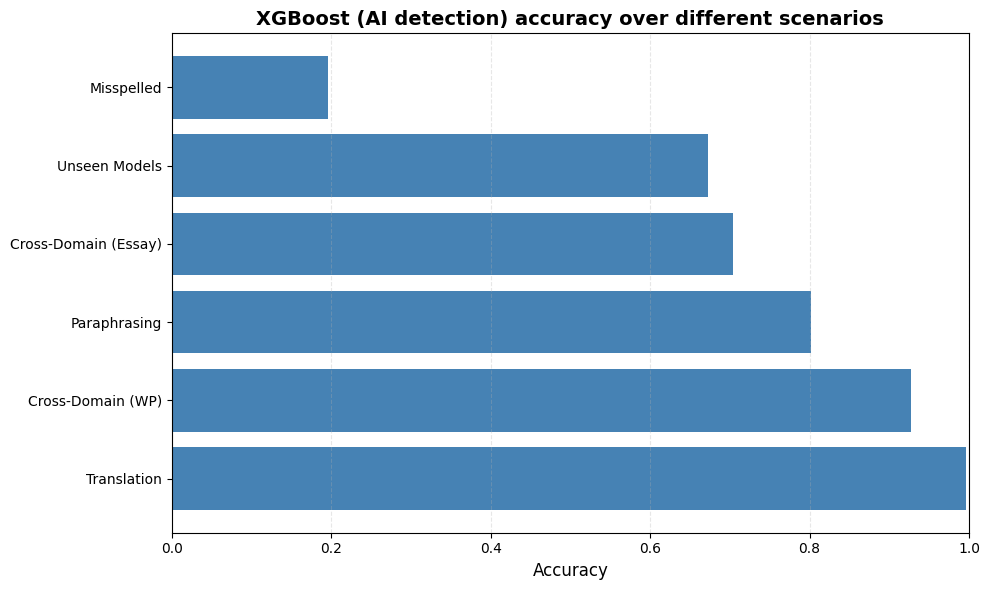


MODEL COMPARISON

       Model  accuracy
 Translation  0.257833
Paraphrasing  0.204040
  Misspelled  0.164394


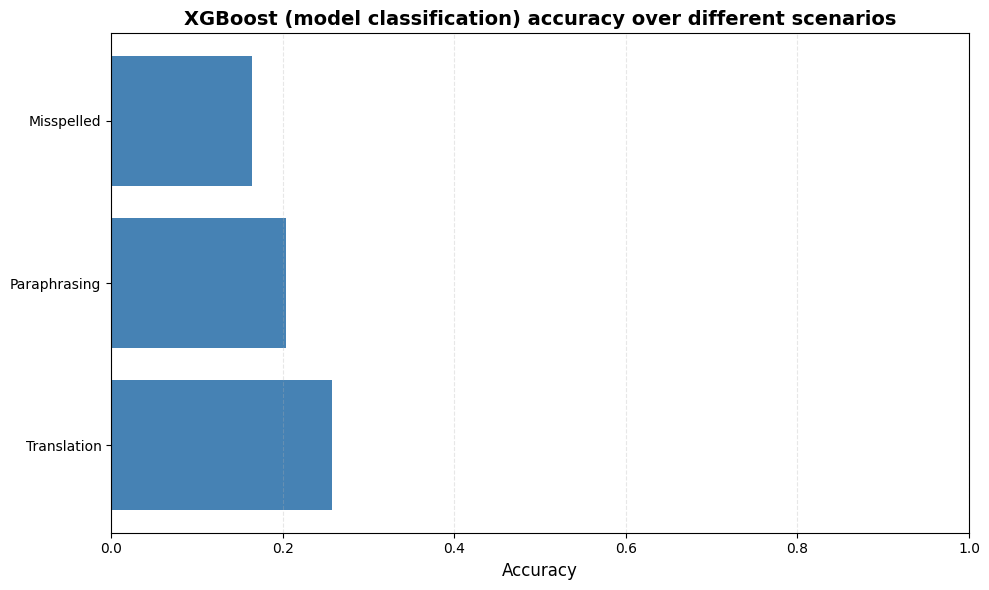

In [ ]:
# 1. Comprehensive Binary Classification Comparison (AI vs Human)
binary_results = {
    'Misspelled': results_misspelled_binary,
    'Misspelled + BERT': results_misspelled_binary_bert,
    'Cross-Domain (Essay)': results_crossdomain_essay_binary,
    'Cross-Domain (Essay) + BERT': results_crossdomain_essay_binary_bert,
    'Cross-Domain (WP)': results_crossdomain_wp_binary,
    'Cross-Domain (WP) + BERT': results_crossdomain_wp_binary_bert,
    'Unseen Models': results_unseen_binary,
    'Unseen Models + BERT': results_unseen_binary_bert,
    'Paraphrasing': results_paraphrase_binary,
    'Paraphrasing + BERT': results_paraphrase_binary_bert,
    'Translation': results_translation_binary,
    'Translation + BERT': results_translation_binary_bert
}

compare_models("XGBoost (AI detection) accuracy over different scenarios", binary_results)


# 2. Comprehensive Multiclass Classification Comparison (Writer Attribution)
multiclass_results = {
    'Misspelled': ts_misspelled_multiclass,
    'Misspelled + BERT': results_misspelled_multiclass_bert,
    'Paraphrasing': results_paraphrase_multiclass,
    'Paraphrasing + BERT': results_paraphrase_multiclass_bert,
    'Translation': results_translation_multiclass,
    'Translation + BERT': results_translation_multiclass_bert
}

compare_models("XGBoost (model classification) accuracy over different scenarios", multiclass_results)